# Imports

In [1]:
import pickle

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

## Utils

In [2]:
def dump_pickle(file_obj, file_path):
    with open(file_path, 'bw') as file:
        pickle.dump(file_obj, file)

In [3]:
def plot_distribution(df: pd.DataFrame, column: str, figsize: tuple[int, int] = (12, 5), bins: str = 'auto', kde: bool = True):
    """
    Plota um Histplot e um Boxplot lado a lado para uma variável contínua.
    
    Parâmetros:
    - df: DataFrame do Pandas
    - coluna: String com o nome da coluna a ser analisada
    - figsize: Tupla (largura, altura) do gráfico
    - bins: Configuração de barras do histograma (padrão 'auto')
    - kde: Booleano para incluir a linha de densidade no histograma (padrão True)
    """
    
    print(f"Max Value: {df[column].max()}")
    print(f"Min Value: {df[column].min()}")
    print(f"Median Value: {df[column].median()}")
    print(f"Mean Value: {df[column].mean()}")
    print(f"STD Value: {df[column].std()}")

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    sns.histplot(data=df, x=column, bins=bins, kde=kde, ax=axes[0], color='#4c72b0')
    axes[0].set_title(f'Histograma de {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequência')
    
    sns.boxplot(data=df, x=column, ax=axes[1], color='#fc8d62')
    axes[1].set_title(f'Boxplot de {column}')
    axes[1].set_xlabel(column)
    
    plt.tight_layout()
    
    plt.show()

In [4]:
def plot_categoricals(df, column: str, figsize: tuple[int, int] = (10, 6)):
    """
    Plota um único gráfico de barras horizontais (Countplot) para uma variável categórica.
    
    Parâmetros:
    - df: DataFrame do Pandas
    - column: String com o nome da coluna categórica
    - figsize: Tupla (largura, altura) do gráfico
    - palette: Paleta de cores do Seaborn
    """
   
    print(df[column].value_counts(True))

    plt.figure(figsize=figsize)
    
    order = df[column].value_counts().index
    
    ax = sns.countplot(data=df, y=column, order=order, color='#4c72b0')
    
    ax.set_title(f'Contagem por {column}', fontsize=14, pad=15)
    ax.set_xlabel('Quantidade')
    ax.set_ylabel(column)
    
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0),
                    textcoords='offset points')
    
    sns.despine(right=True, top=True)
    
    plt.tight_layout()
    plt.show()

In [5]:
def plot_cat_vs_target(df, col_categorica: str, col_target: str, target_sucesso: str, figsize: tuple[int, int] = (20, 7)):
    """
    Plota lado a lado a taxa de uma classe específica (sucesso) vs média global (esquerda) 
    e a proporção empilhada 100% de todas as classes do target (direita) para uma variável categórica.
    """
    # Criando a estrutura de 1 linha e 2 colunas lado a lado
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # =========================================================================
    # GRÁFICO 1 (ESQUERDA - axes[0]): Taxa de Sucesso vs Média Global
    # =========================================================================
    df_temp = df.copy()
    # Cria uma flag binária para a classe escolhida como sucesso
    df_temp['is_target'] = (df_temp[col_target].astype(str) == str(target_sucesso)).astype(int)
    
    taxa_por_cat = df_temp.groupby(col_categorica)['is_target'].mean() * 100
    taxa_por_cat = taxa_por_cat.sort_values(ascending=False).reset_index()
    media_global = df_temp['is_target'].mean() * 100
    
    # Plot das barras horizontais azuis
    sns.barplot(
        data=taxa_por_cat, 
        y=col_categorica, 
        x='is_target', 
        color='#4f81bd', 
        width=0.6,
        ax=axes[0]
    )
    
    # Linha da média global laranja
    axes[0].axvline(
        x=media_global, 
        color='#e46c0a', 
        linestyle='--', 
        linewidth=2, 
        label=f'Média Global ({media_global:.1f}%)'
    )
    
    axes[0].set_title(f'Taxa de "{target_sucesso}" em {col_target} por {col_categorica}', fontsize=13, pad=15)
    axes[0].set_xlabel(f'Percentual de "{target_sucesso}" (%)')
    axes[0].set_ylabel(col_categorica)
    axes[0].legend(loc='lower right')
    
    # Rótulos nas barras azuis (Note o uso de axes[0].containers)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold')

    # =========================================================================
    # GRÁFICO 2 (DIREITA - axes[1]): Proporção Empilhada 100% (Multiclasse)
    # =========================================================================
    # Cria a tabela cruzada com todas as classes
    crosstab = pd.crosstab(df[col_categorica], df[col_target])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    
    # Ordena pela categoria que tem maior presença da classe de sucesso (para manter consistência)
    if target_sucesso in crosstab_pct.columns:
        crosstab_pct = crosstab_pct.sort_values(by=target_sucesso, ascending=False)
    
    # Gera cores dinamicamente a partir do Set2 ou color_palette do seaborn de acordo com o número de classes
    num_classes = len(crosstab_pct.columns)
    cores = sns.color_palette("Set2", n_colors=num_classes)
    
    # Plot das barras empilhadas direcionando para o axes[1]
    crosstab_pct.plot(
        kind='barh', 
        stacked=True, 
        color=cores, 
        width=0.7, 
        ax=axes[1]
    )

    axes[1].set_title(f'Proporção de {col_target} por Categoria de {col_categorica}', fontsize=13, pad=15)
    axes[1].set_xlabel('Percentual (%)')
    axes[1].set_ylabel('') 
    axes[1].set_xlim(0, 100)
    axes[1].legend(title=col_target, bbox_to_anchor=(1.02, 1), loc='upper left')

    # Rótulos internos nas barras empilhadas utilizando o container nativo do matplotlib
    for container in axes[1].containers:
        labels = [f'{valor.get_width():.1f}%' if valor.get_width() > 5 else '' for valor in container]
        axes[1].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

    # Customizações finais de layout para ambos os eixos
    sns.despine(ax=axes[0], top=True, right=True)
    sns.despine(ax=axes[1], top=True, right=True)
    
    plt.tight_layout()
    plt.show()

In [6]:
def plot_num_vs_target(df, col_numerica: str, col_target: str, figsize: tuple[int, int] = (14, 5)):
    """
    Plota a relação entre uma variável numérica e uma variável categórica target (Multiclasse).
    Gera automaticamente uma paleta de cores baseada nas classes existentes.
    """
    # Identifica as classes únicas do target de forma dinâmica
    classes_unicas = sorted(df[col_target].dropna().unique())
    num_classes = len(classes_unicas)
    
    # Cria o dicionário de cores dinâmico usando a paleta Set2 (ou outra de sua preferência)
    cores_lista = sns.color_palette("Set2", n_colors=num_classes)
    palette_dict = {classe: cor for classe, cor in zip(classes_unicas, cores_lista)}

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 1. Boxplot (Esquerda) - Funciona perfeitamente com multiclasse
    sns.boxplot(
        data=df, 
        x=col_target, 
        y=col_numerica, 
        hue=col_target, 
        legend=False, 
        ax=axes[0], 
        palette=palette_dict
    )
    axes[0].set_title(f'Distribuição de {col_numerica} por {col_target}')
    axes[0].set_xlabel(col_target)
    axes[0].set_ylabel(col_numerica)
    
    # 2. KDE Plot (Direita) - Substituído o Barplot por um gráfico de densidade,
    # que é o ideal para comparar distribuições numéricas entre múltiplas classes.
    sns.kdeplot(
        data=df,
        x=col_numerica,
        hue=col_target,
        fill=True,
        common_norm=False,  # Permite avaliar o formato de cada classe de forma independente
        alpha=0.4,
        palette=palette_dict,
        ax=axes[1]
    )
    axes[1].set_title(f'Densidade (KDE) de {col_numerica} por {col_target}')
    axes[1].set_xlabel(col_numerica)
    axes[1].set_ylabel('Densidade')
    
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

# Loading Datasets

In [7]:
df = pd.read_csv('../data/train.csv', index_col='id')
df_test = pd.read_csv('../data/test.csv', index_col='id')

In [8]:
df.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [9]:
df.tail()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO
577346,194.633820,-1.307079,21.244353,21.101997,20.809379,20.866345,20.495411,1.101004,A/F,Blue_Cloud,QSO


## Data Columns

In [10]:
df.columns.tolist()

['alpha',
 'delta',
 'u',
 'g',
 'r',
 'i',
 'z',
 'redshift',
 'spectral_type',
 'galaxy_population',
 'class']

## Data Dimensions

In [11]:
df.shape

(577347, 11)

## Data NA

In [12]:
df.isna().mean()

alpha                0.0
delta                0.0
u                    0.0
g                    0.0
r                    0.0
i                    0.0
z                    0.0
redshift             0.0
spectral_type        0.0
galaxy_population    0.0
class                0.0
dtype: float64

## Data Types

In [13]:
df.dtypes

alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object

# Exploratory Data Analysis

## Univariate Data Analysis

### alpha

Max Value: 359.999809770956
Min Value: 0.0116837460479923
Median Value: 188.681465455706
Mean Value: 181.6166725014324
STD Value: 96.24294081297191


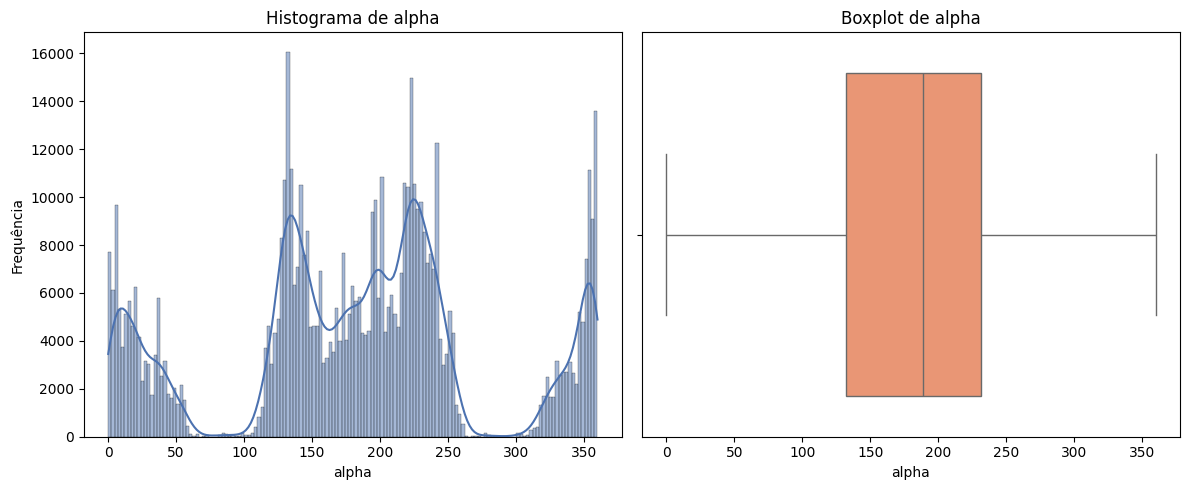

In [14]:
plot_distribution(df, 'alpha')

### delta

Max Value: 79.158322400569
Min Value: -17.9669875155677
Median Value: 21.4844118395961
Mean Value: 21.83465436901883
STD Value: 18.933570378361278


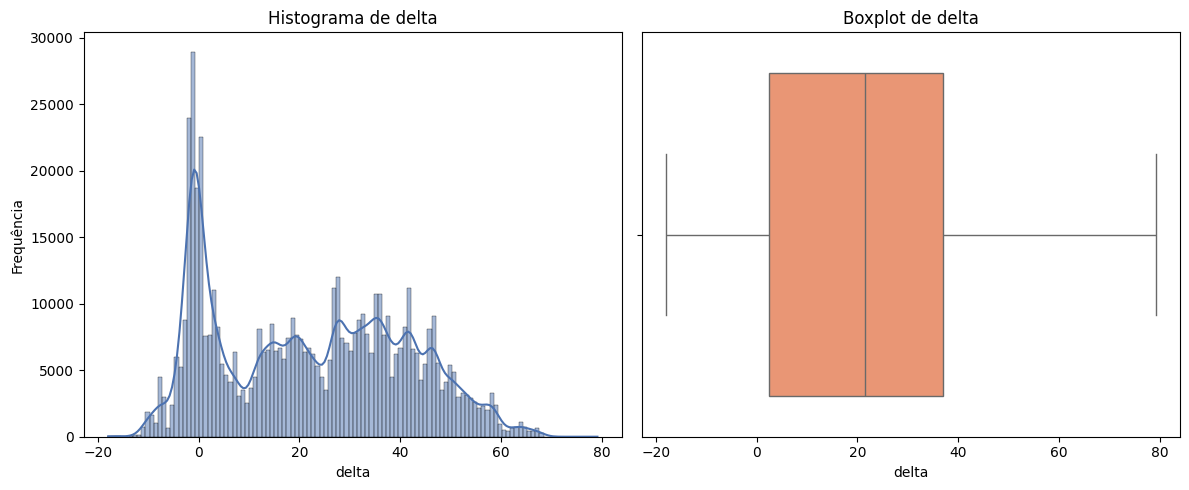

In [15]:
plot_distribution(df, 'delta')

### u

Max Value: 28.253263322937897
Min Value: -0.1392249436681481
Median Value: 22.570221914219115
Mean Value: 22.441925526872602
STD Value: 2.018134839641773


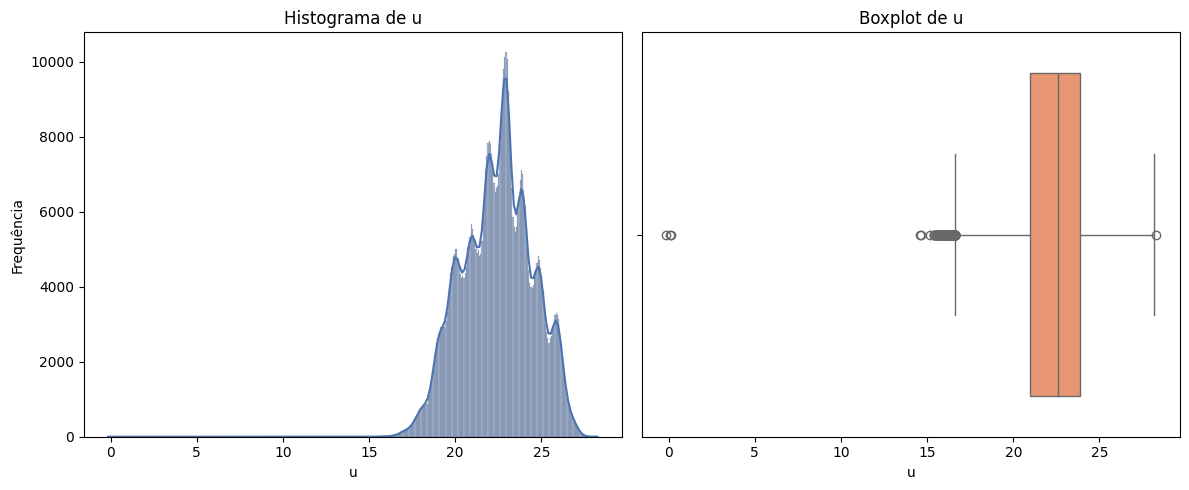

In [16]:
plot_distribution(df, 'u')

### g

Max Value: 27.62020771336905
Min Value: 13.535483058678922
Median Value: 21.4678198688169
Mean Value: 21.007273390353177
STD Value: 1.7954255417667804


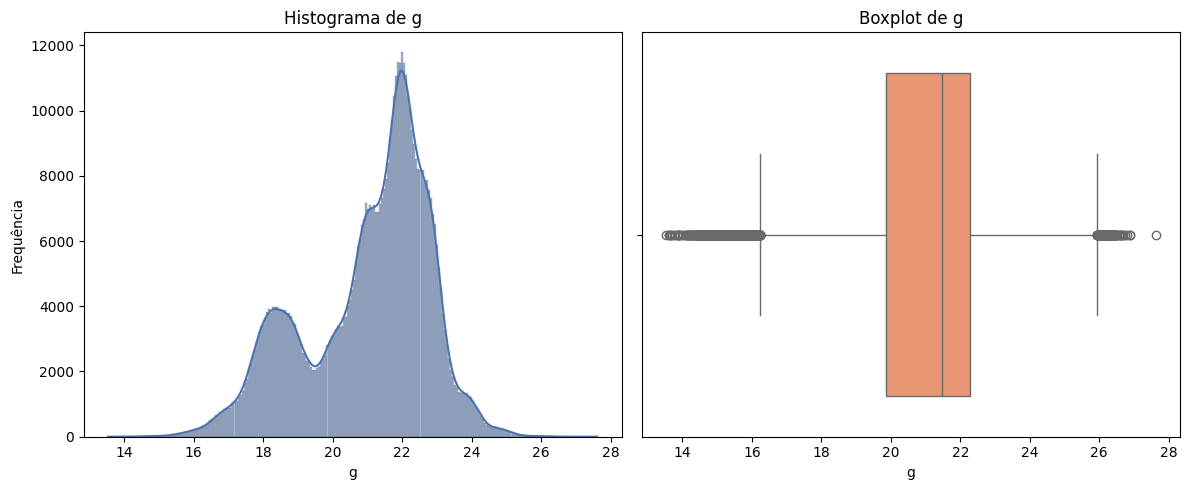

In [17]:
plot_distribution(df, 'g')

### r

Max Value: 25.254499197443124
Min Value: 12.57940713826054
Median Value: 20.4311530012024
Mean Value: 19.962810540029647
STD Value: 1.6489635664616693


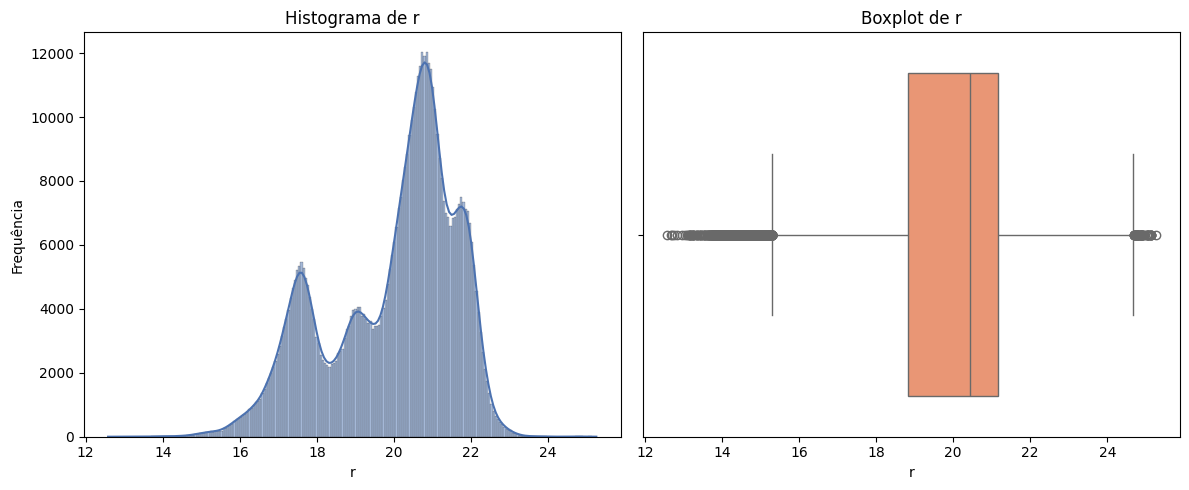

In [18]:
plot_distribution(df, 'r')

### i

Max Value: 27.9108531624854
Min Value: 11.962781454848429
Median Value: 19.631642148048154
Mean Value: 19.378910895517517
STD Value: 1.580059191820495


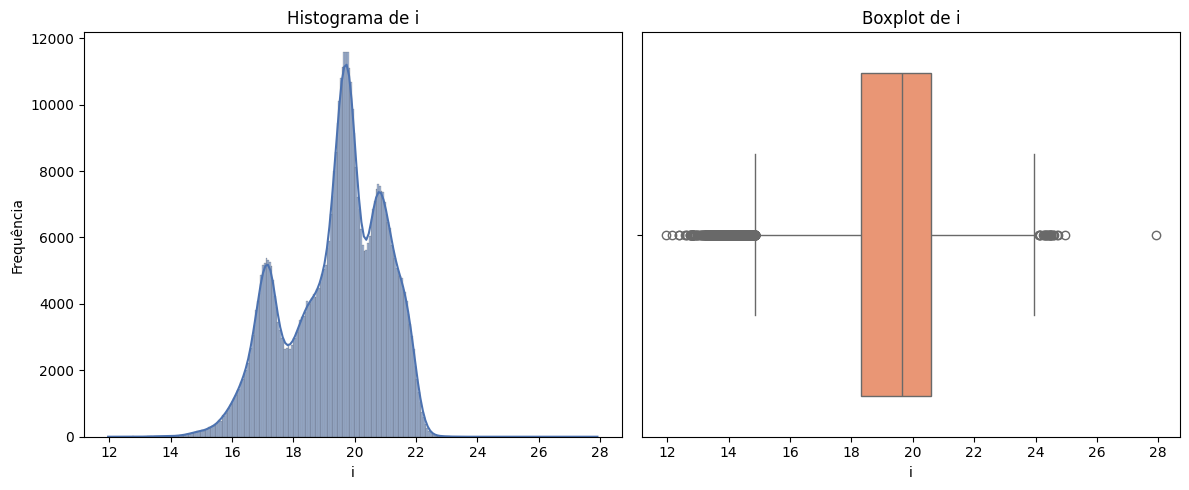

In [19]:
plot_distribution(df, 'i')

### z

Max Value: 26.82686689523431
Min Value: 11.68280337896474
Median Value: 19.18859827341141
Mean Value: 19.041135950117635
STD Value: 1.5843652902608267


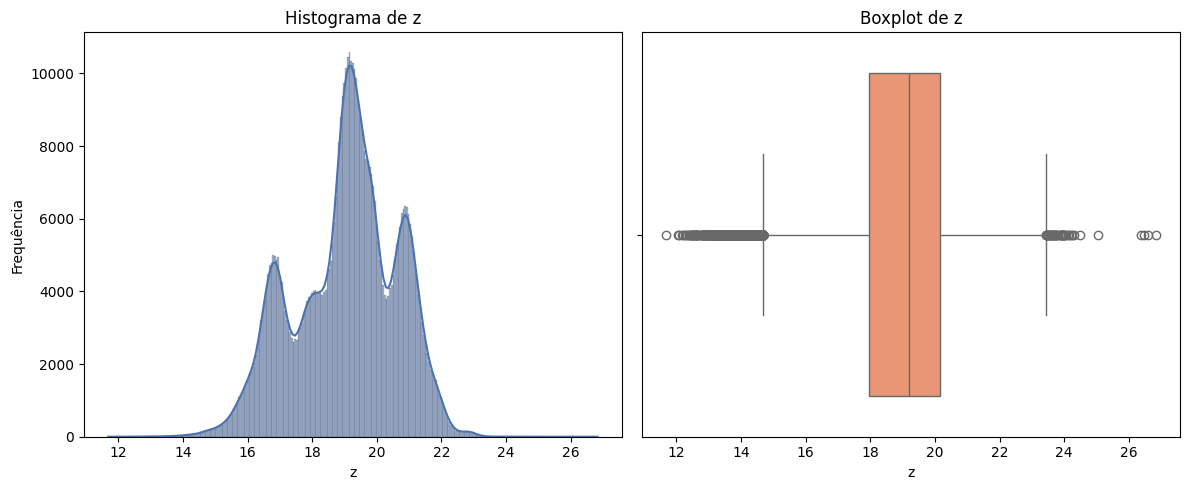

In [20]:
plot_distribution(df, 'z')

### redshift

Max Value: 7.010780492217193
Min Value: -0.0099703582110835
Median Value: 0.4975245994478717
Mean Value: 0.7231354437546343
STD Value: 0.8100700103799541


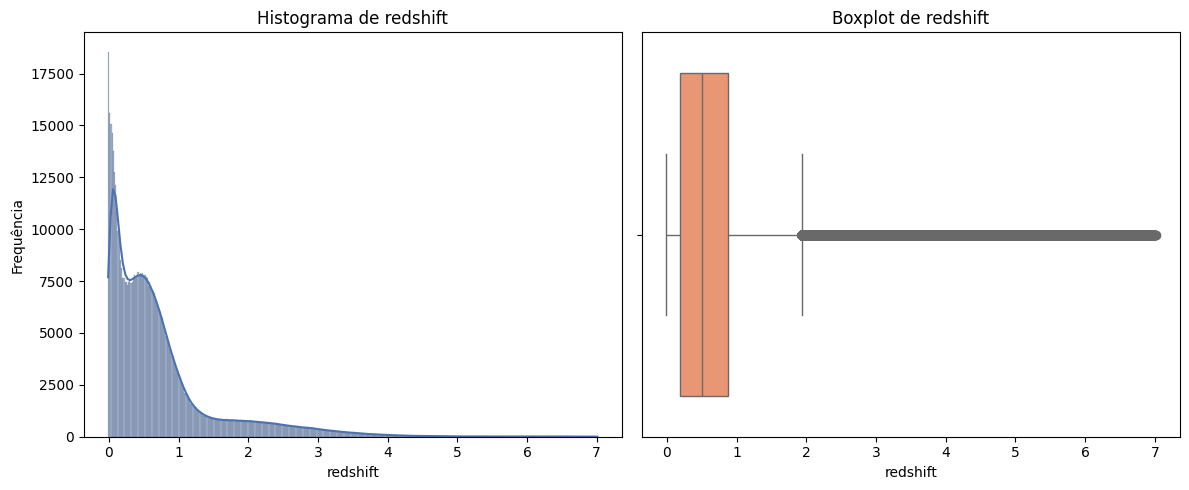

In [21]:
plot_distribution(df, 'redshift')

### spectral_type

spectral_type
M      0.525374
A/F    0.211523
G/K    0.188008
O/B    0.075095
Name: proportion, dtype: float64


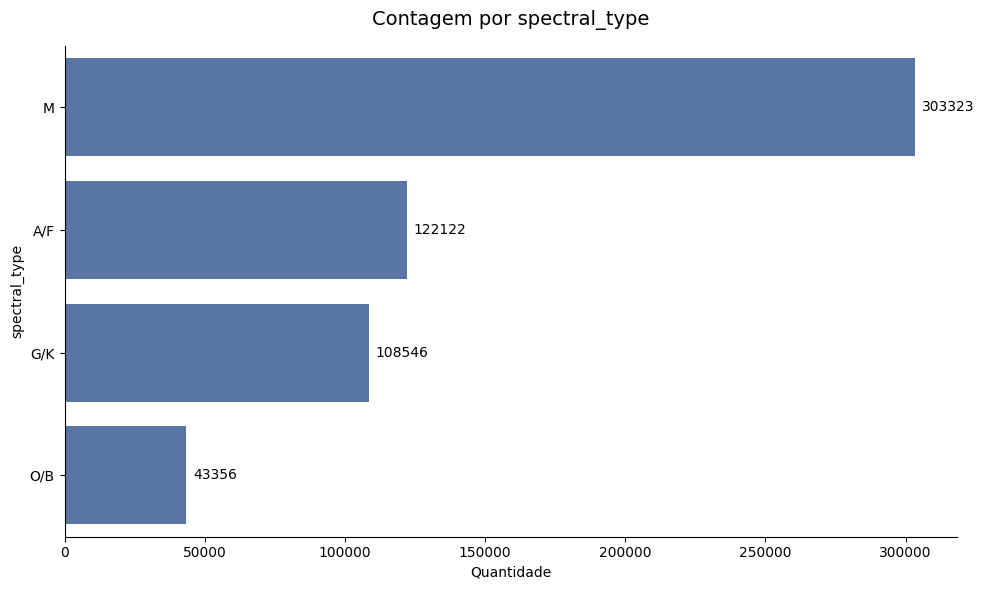

In [22]:
plot_categoricals(df, 'spectral_type')

### galaxy_population

galaxy_population
Red_Sequence    0.553506
Blue_Cloud      0.446494
Name: proportion, dtype: float64


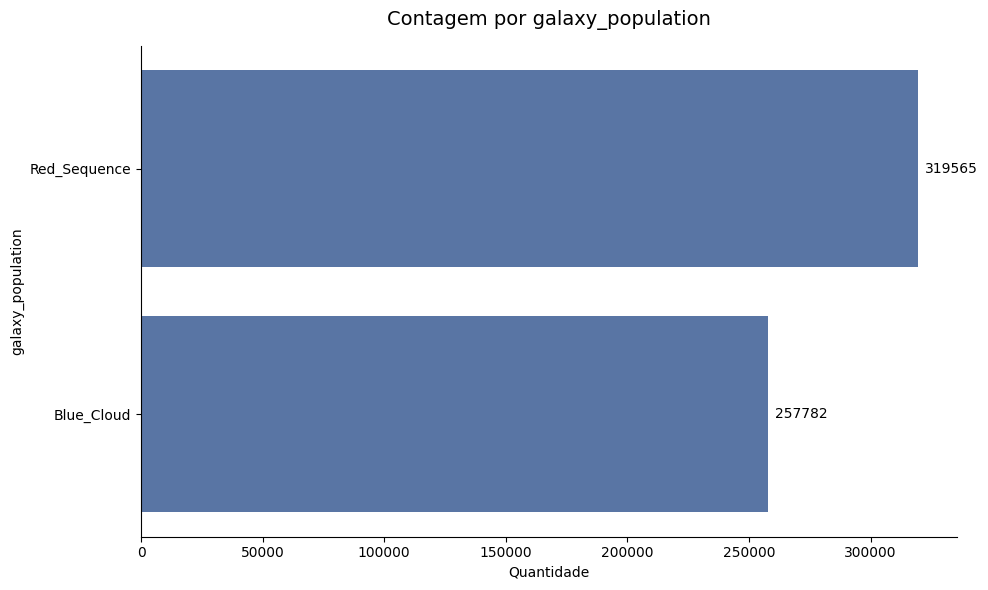

In [23]:
plot_categoricals(df, 'galaxy_population')

### class

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64


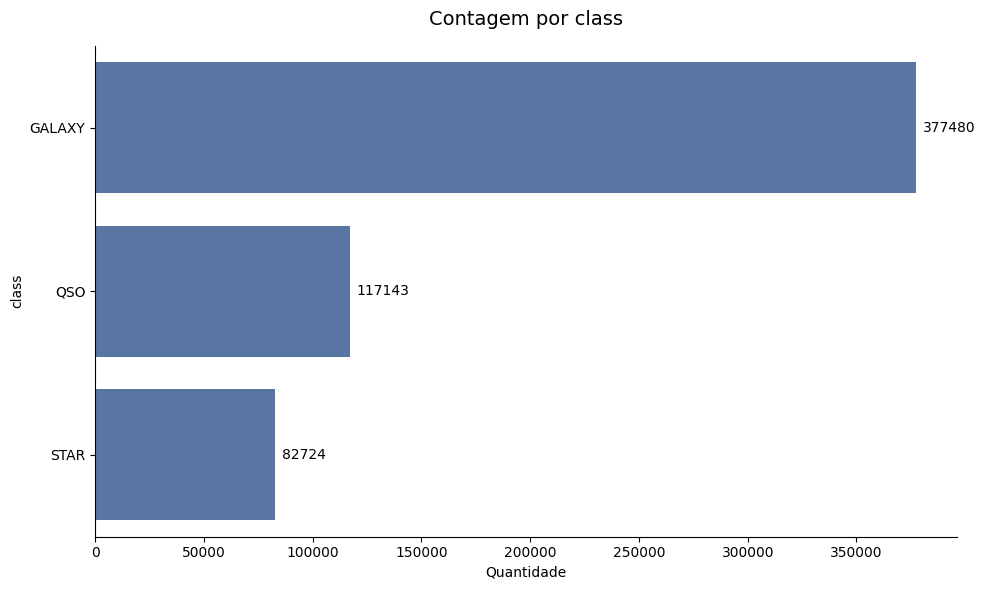

In [24]:
plot_categoricals(df, 'class')

## Bivariate Analysis

### alpha vs class

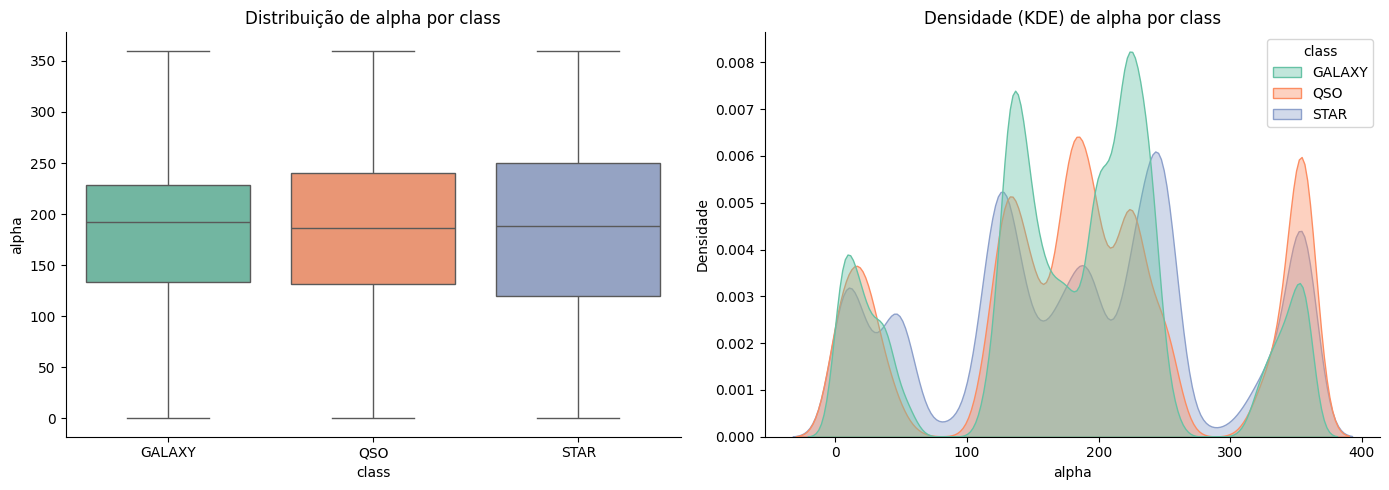

In [25]:
plot_num_vs_target(df, col_numerica='alpha', col_target='class')

### delta vs class

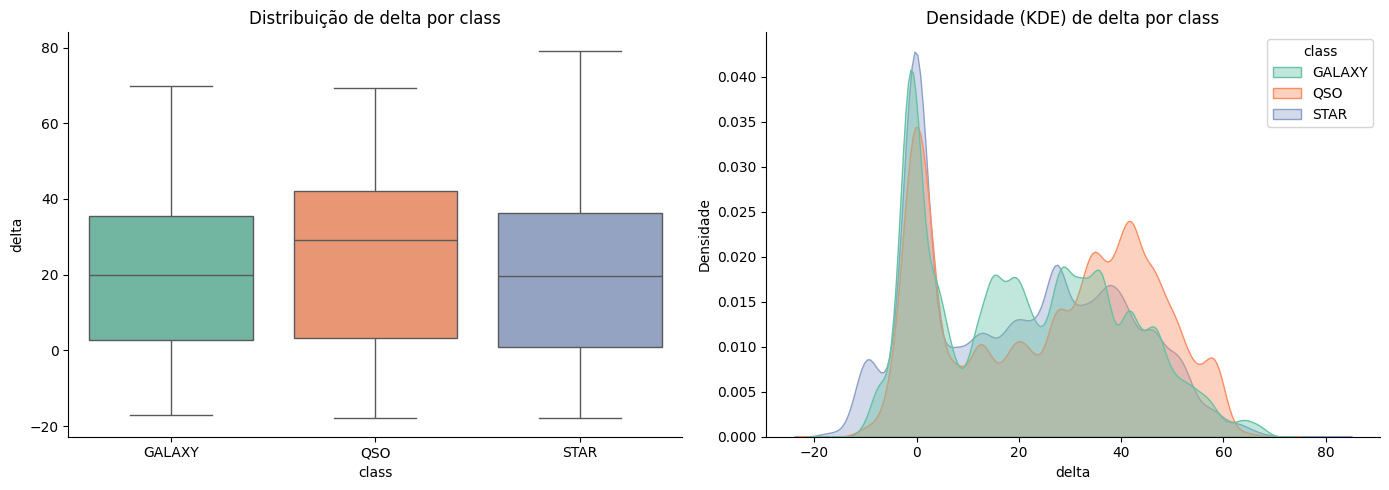

In [26]:
plot_num_vs_target(df, col_numerica='delta', col_target='class')

### u vs class

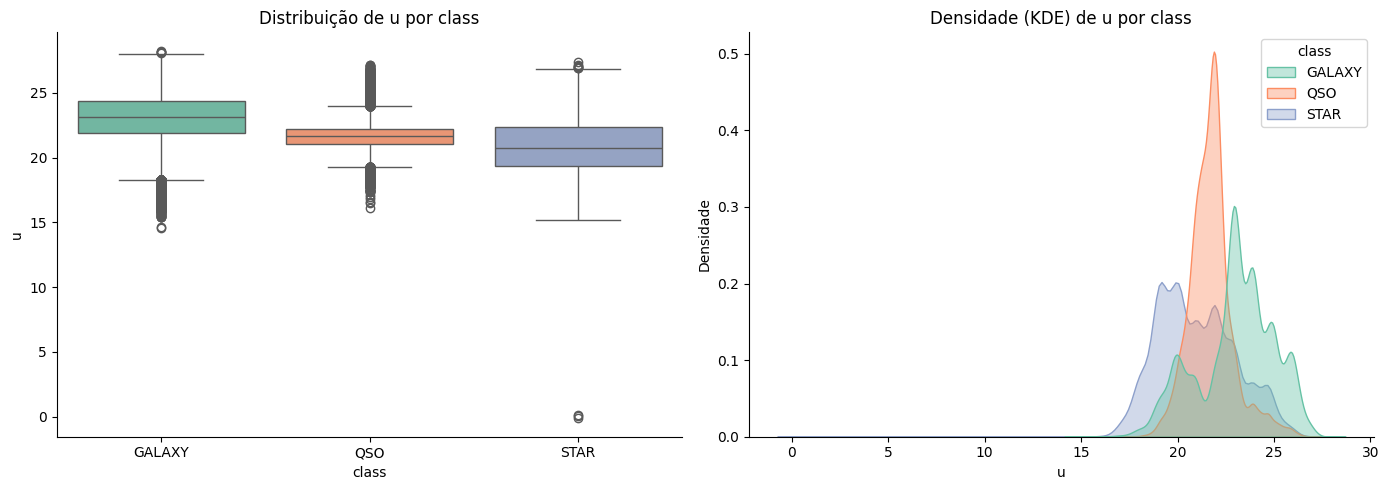

In [27]:
plot_num_vs_target(df, col_numerica='u', col_target='class')

### g vs class

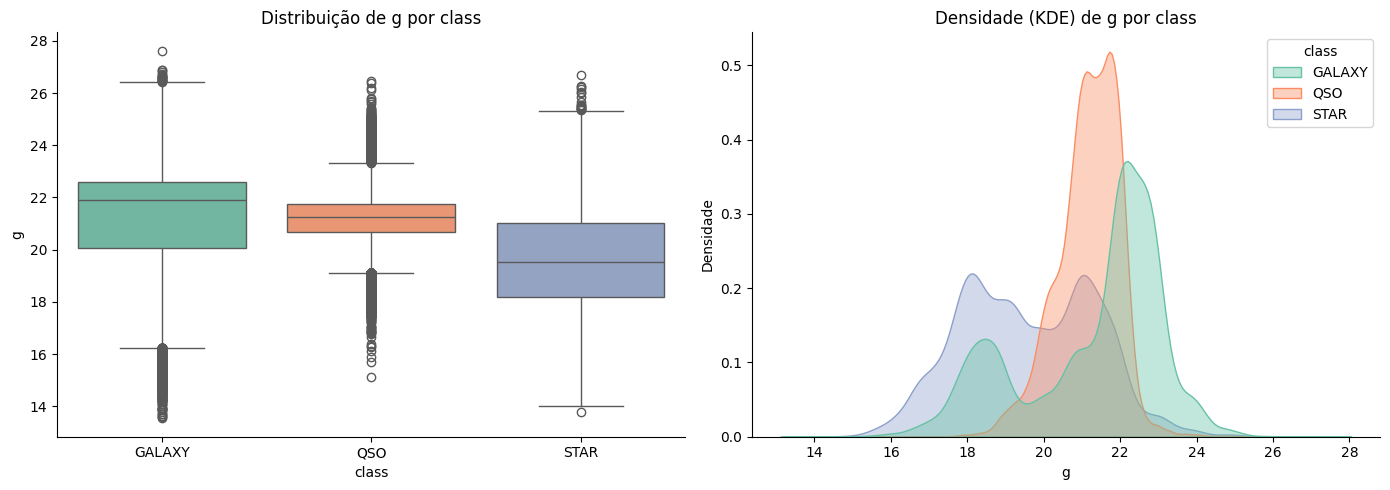

In [28]:
plot_num_vs_target(df, col_numerica='g', col_target='class')

### r vs class

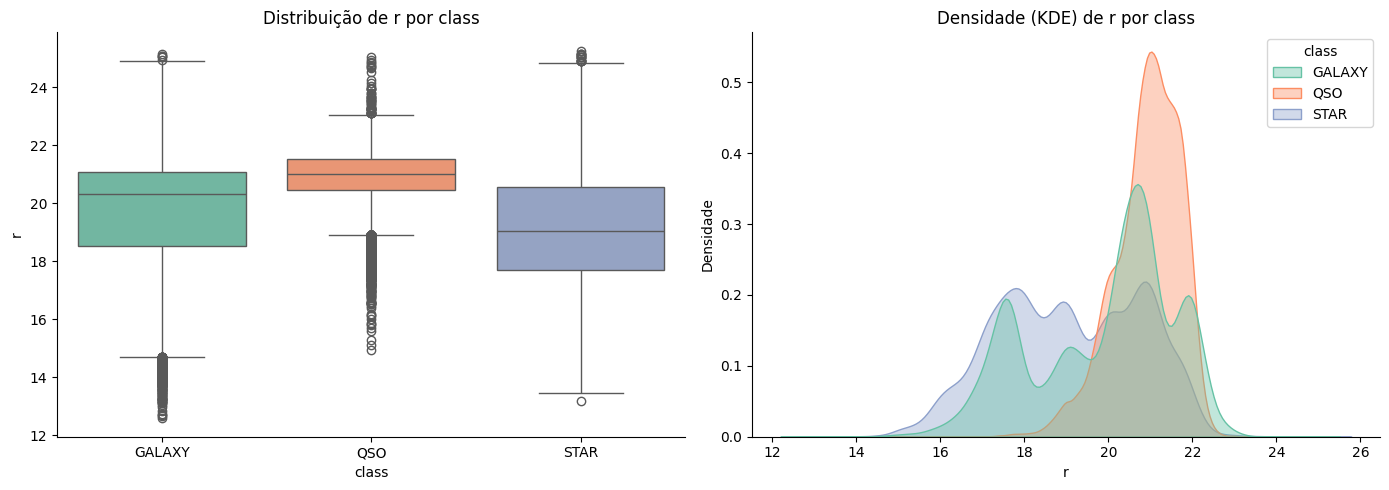

In [29]:
plot_num_vs_target(df, col_numerica='r', col_target='class')

### i vs class

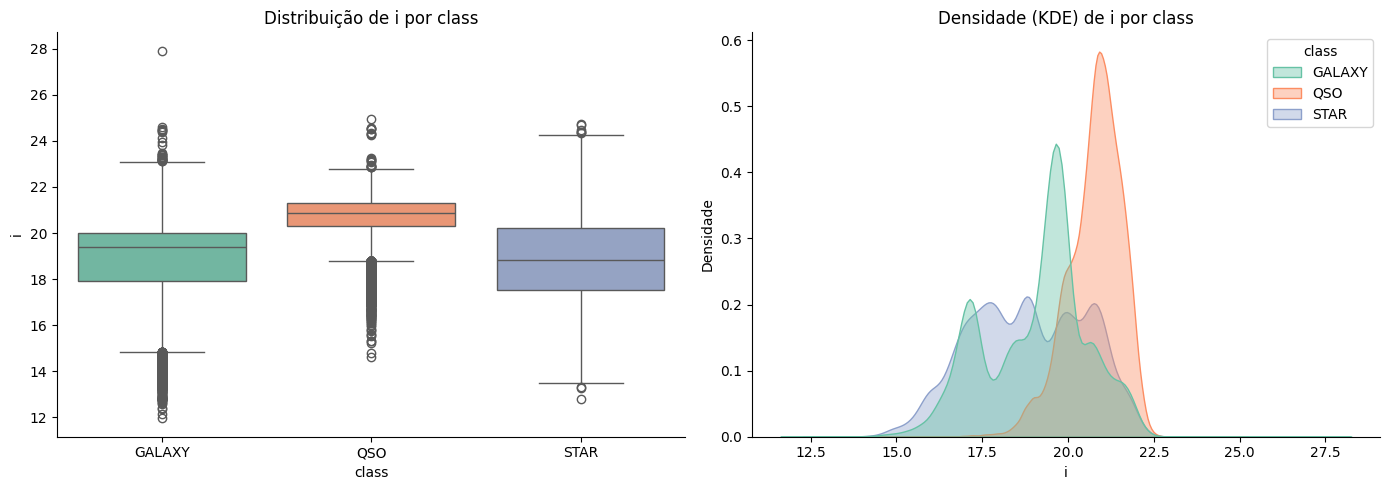

In [30]:
plot_num_vs_target(df, col_numerica='i', col_target='class')

### z vs class

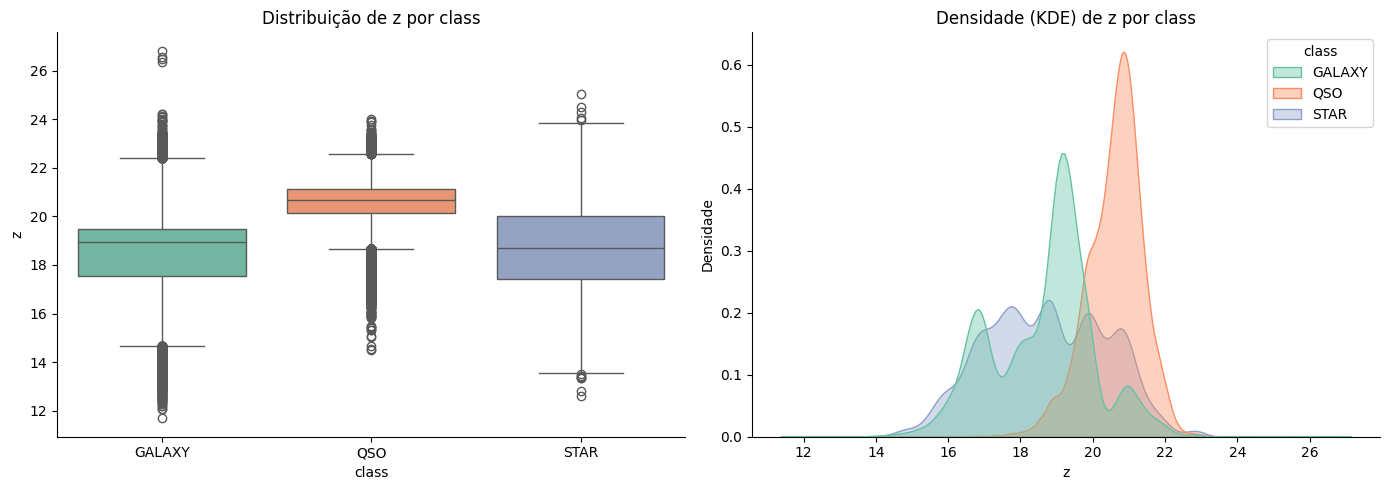

In [31]:
plot_num_vs_target(df, col_numerica='z', col_target='class')

### redshift vs class

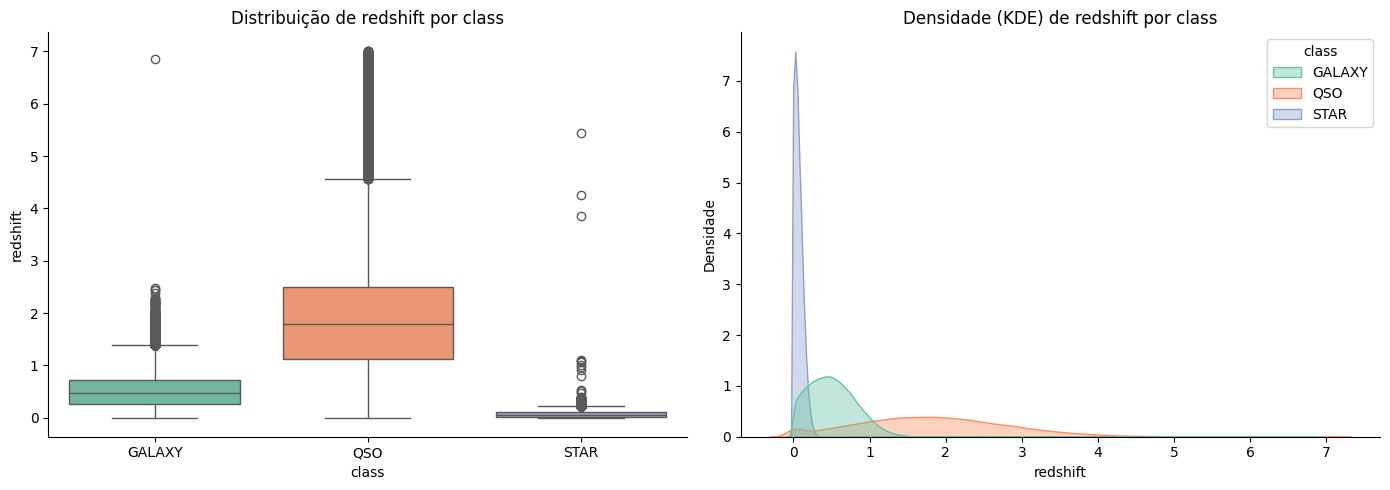

In [32]:
plot_num_vs_target(df, col_numerica='redshift', col_target='class')

### spectral_type vs class

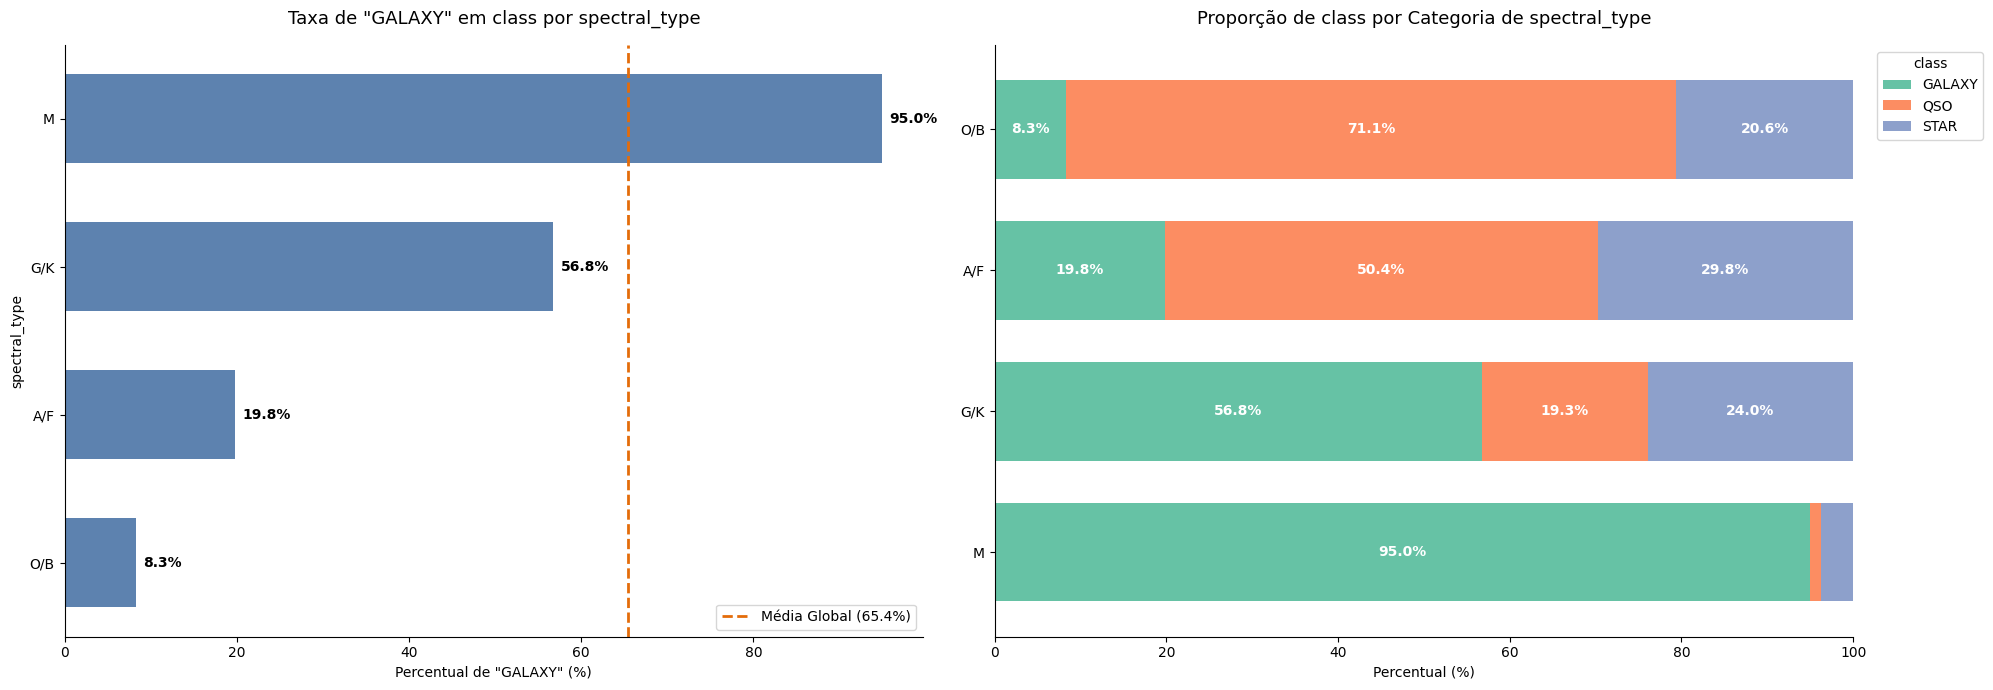

In [33]:
plot_cat_vs_target(df, col_categorica='spectral_type', col_target='class', target_sucesso='GALAXY')

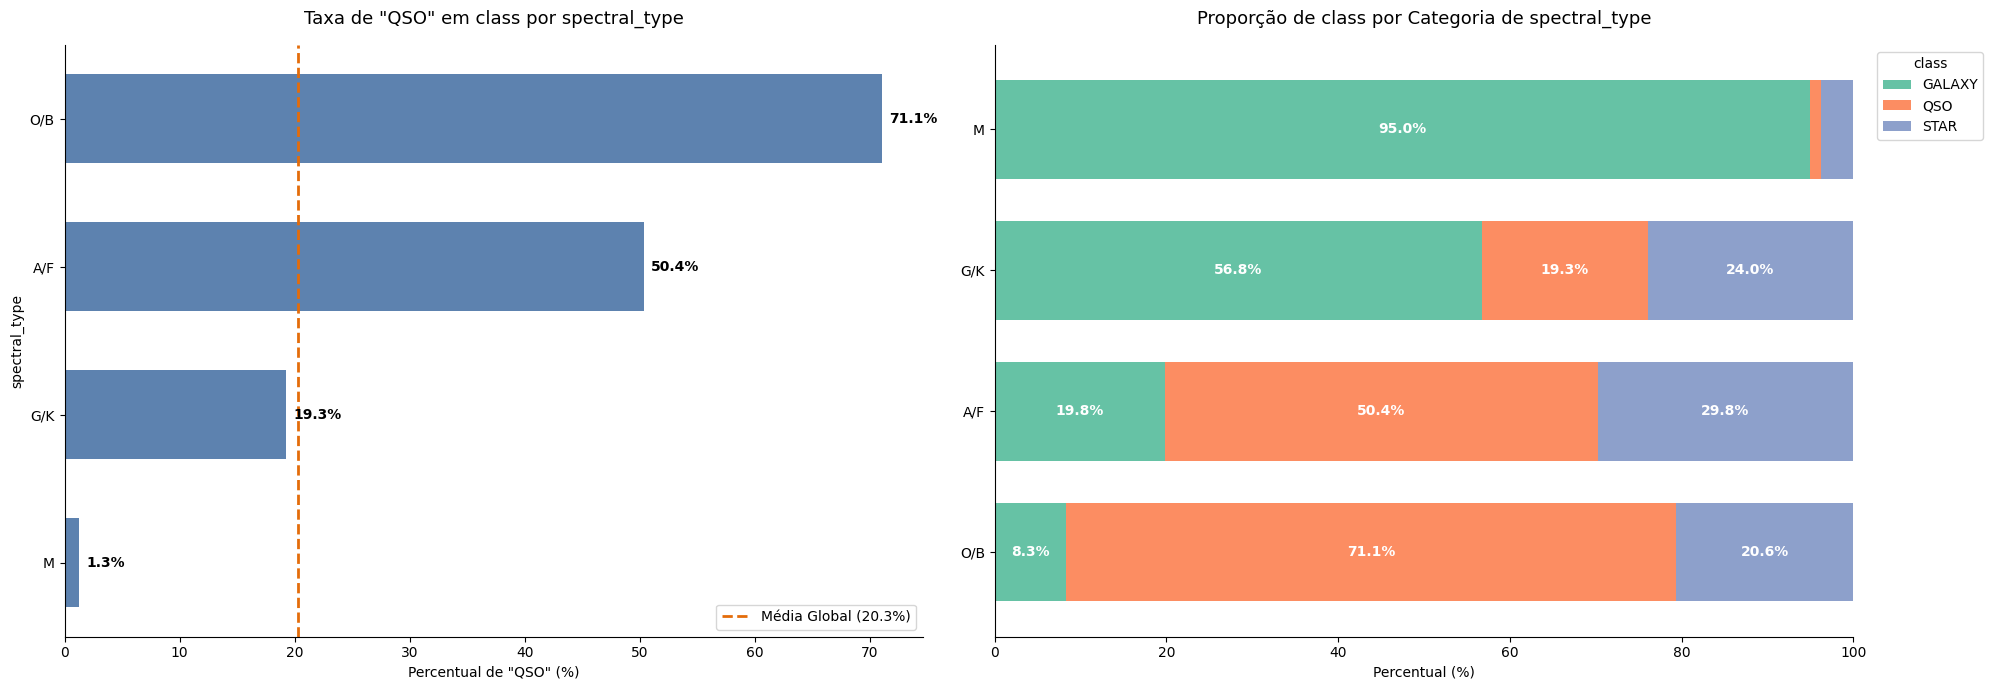

In [34]:
plot_cat_vs_target(df, col_categorica='spectral_type', col_target='class', target_sucesso='QSO')

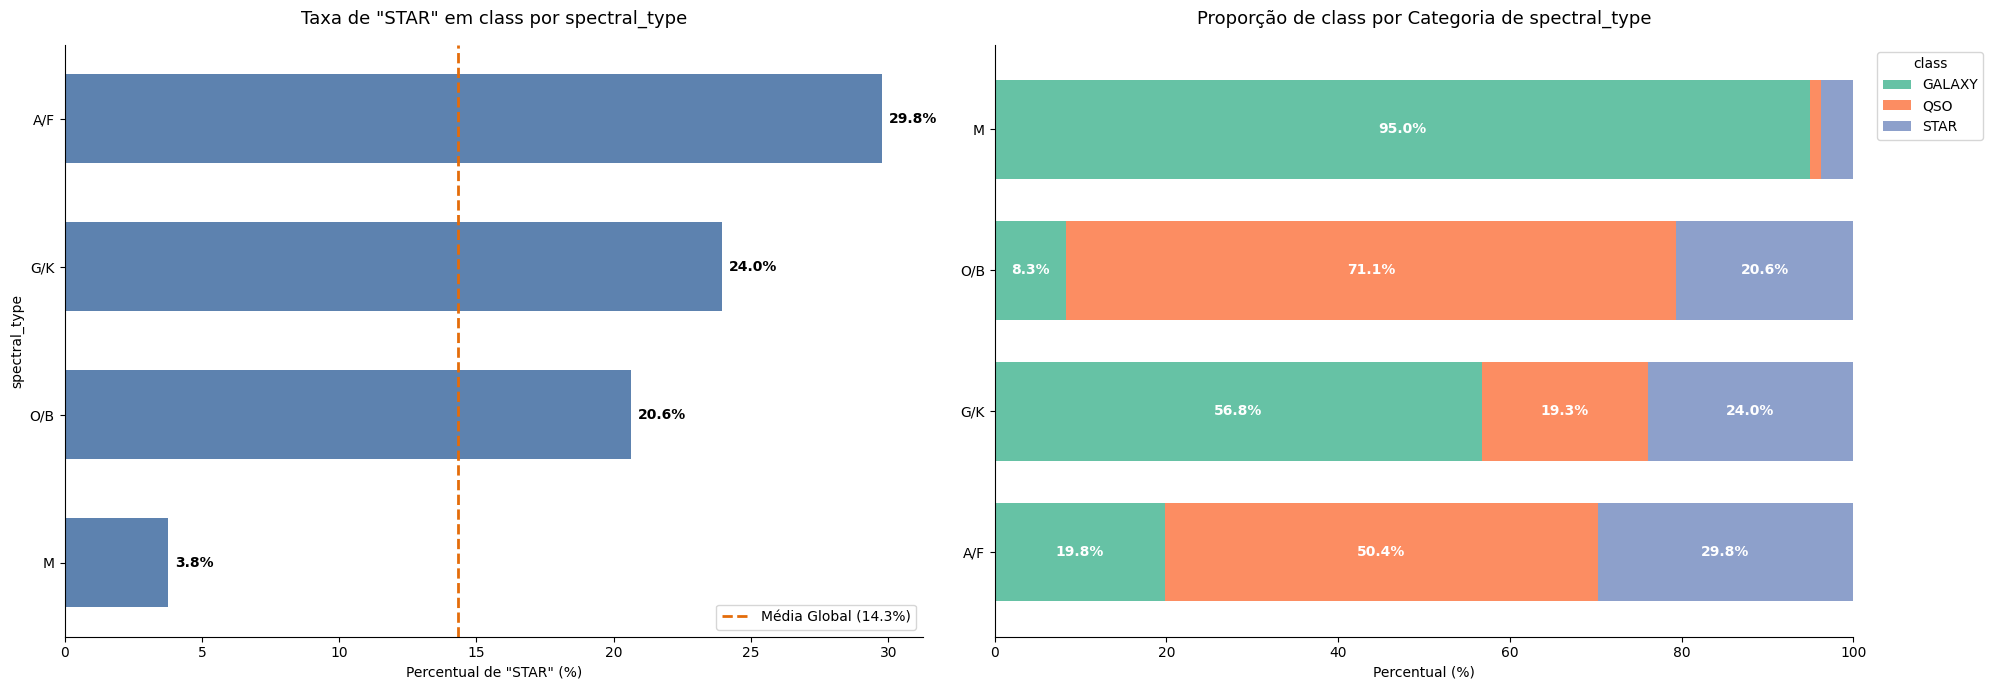

In [35]:
plot_cat_vs_target(df, col_categorica='spectral_type', col_target='class', target_sucesso='STAR')

### galaxy_population vs class

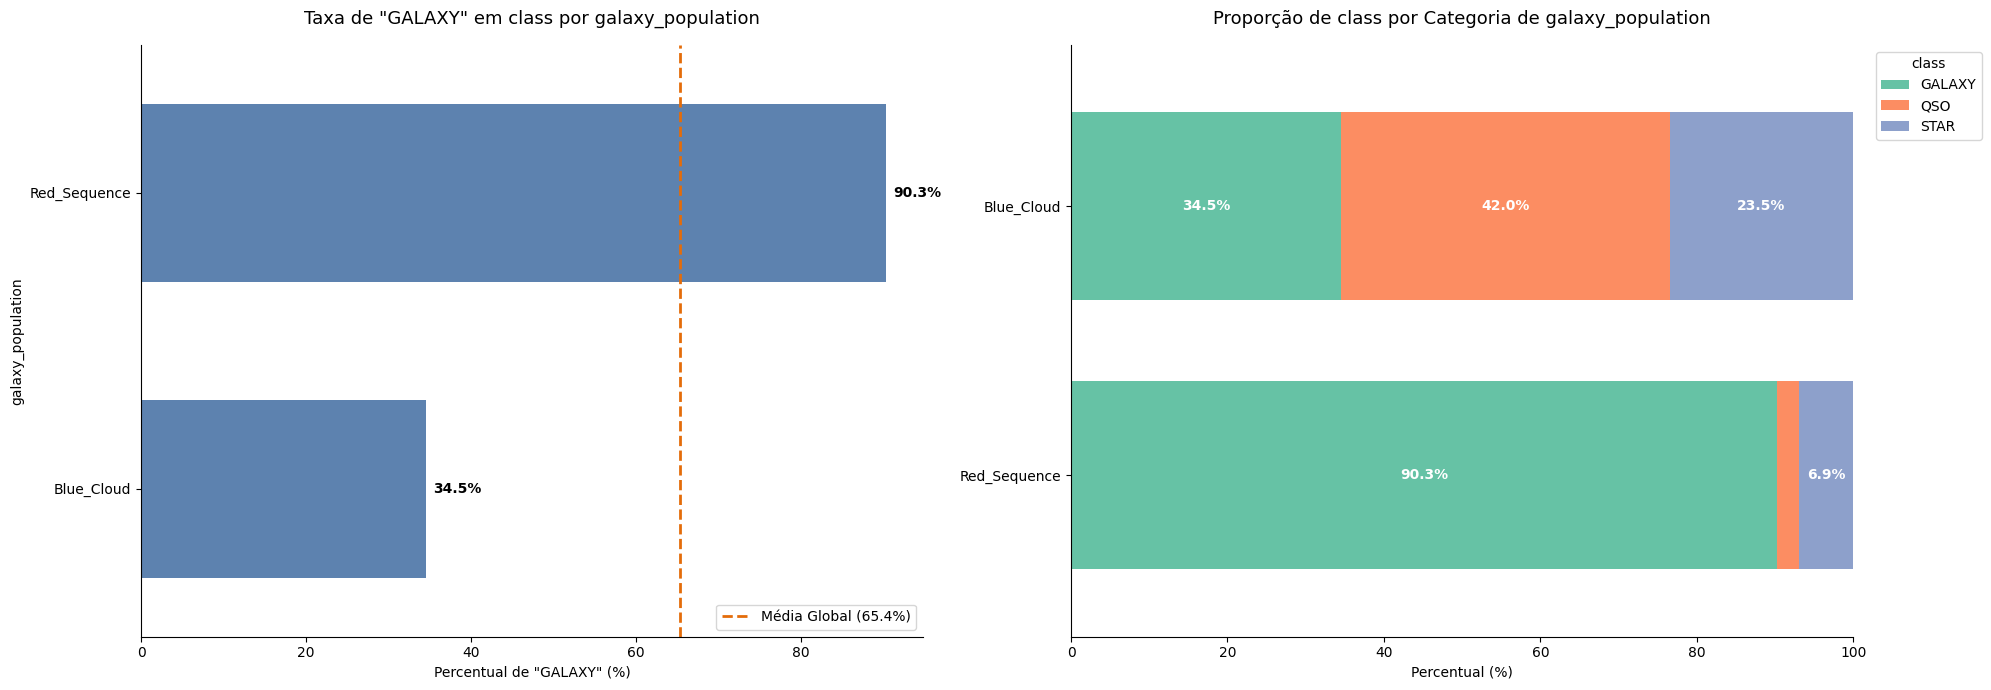

In [36]:
plot_cat_vs_target(df, col_categorica='galaxy_population', col_target='class', target_sucesso='GALAXY')

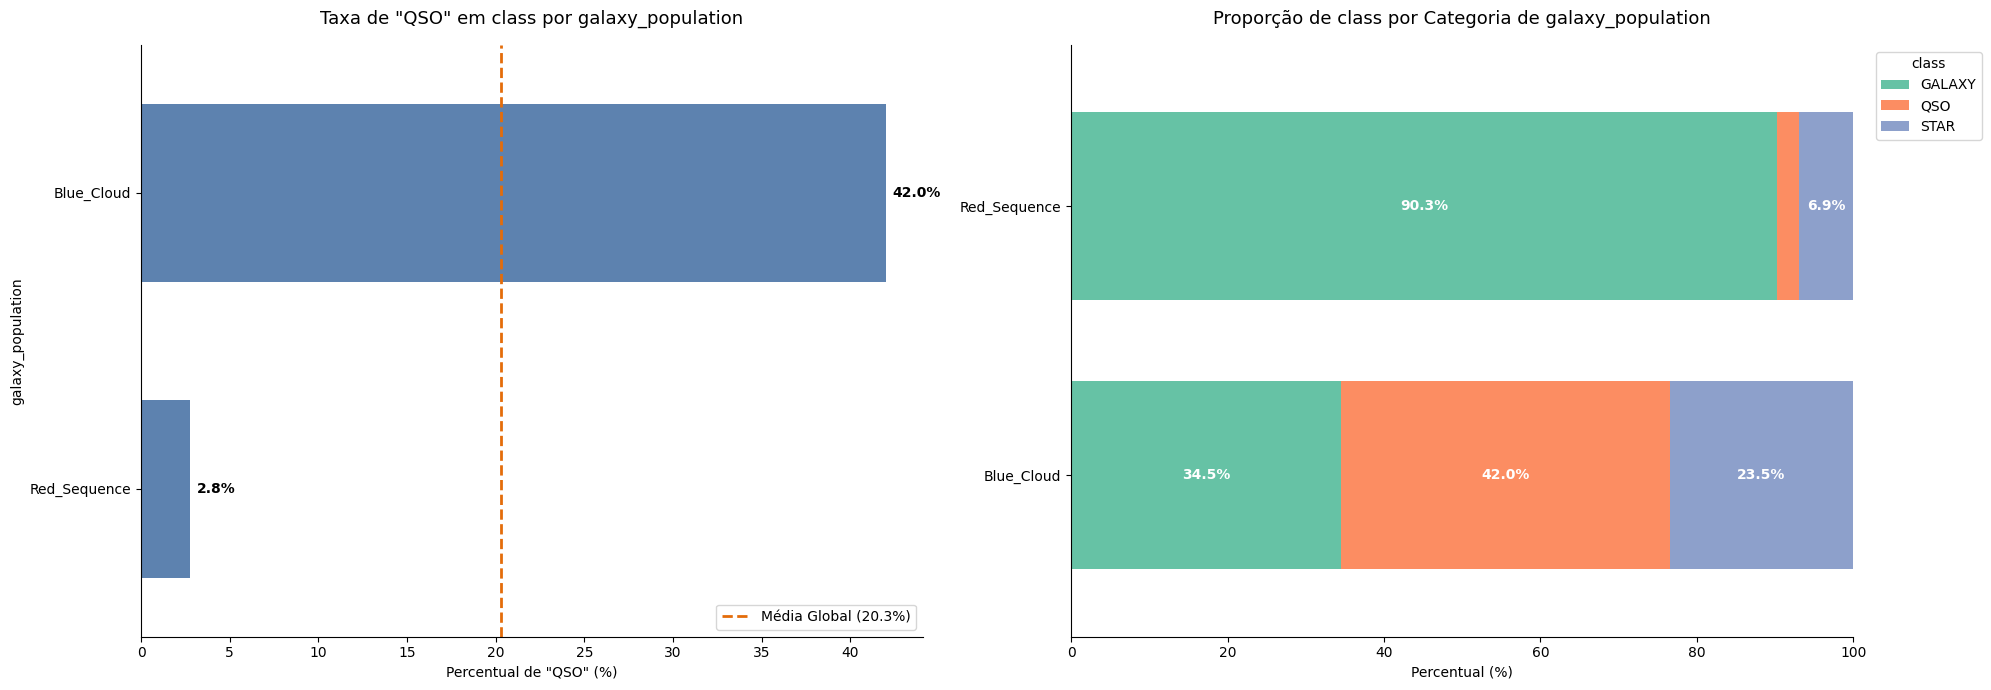

In [37]:
plot_cat_vs_target(df, col_categorica='galaxy_population', col_target='class', target_sucesso='QSO')

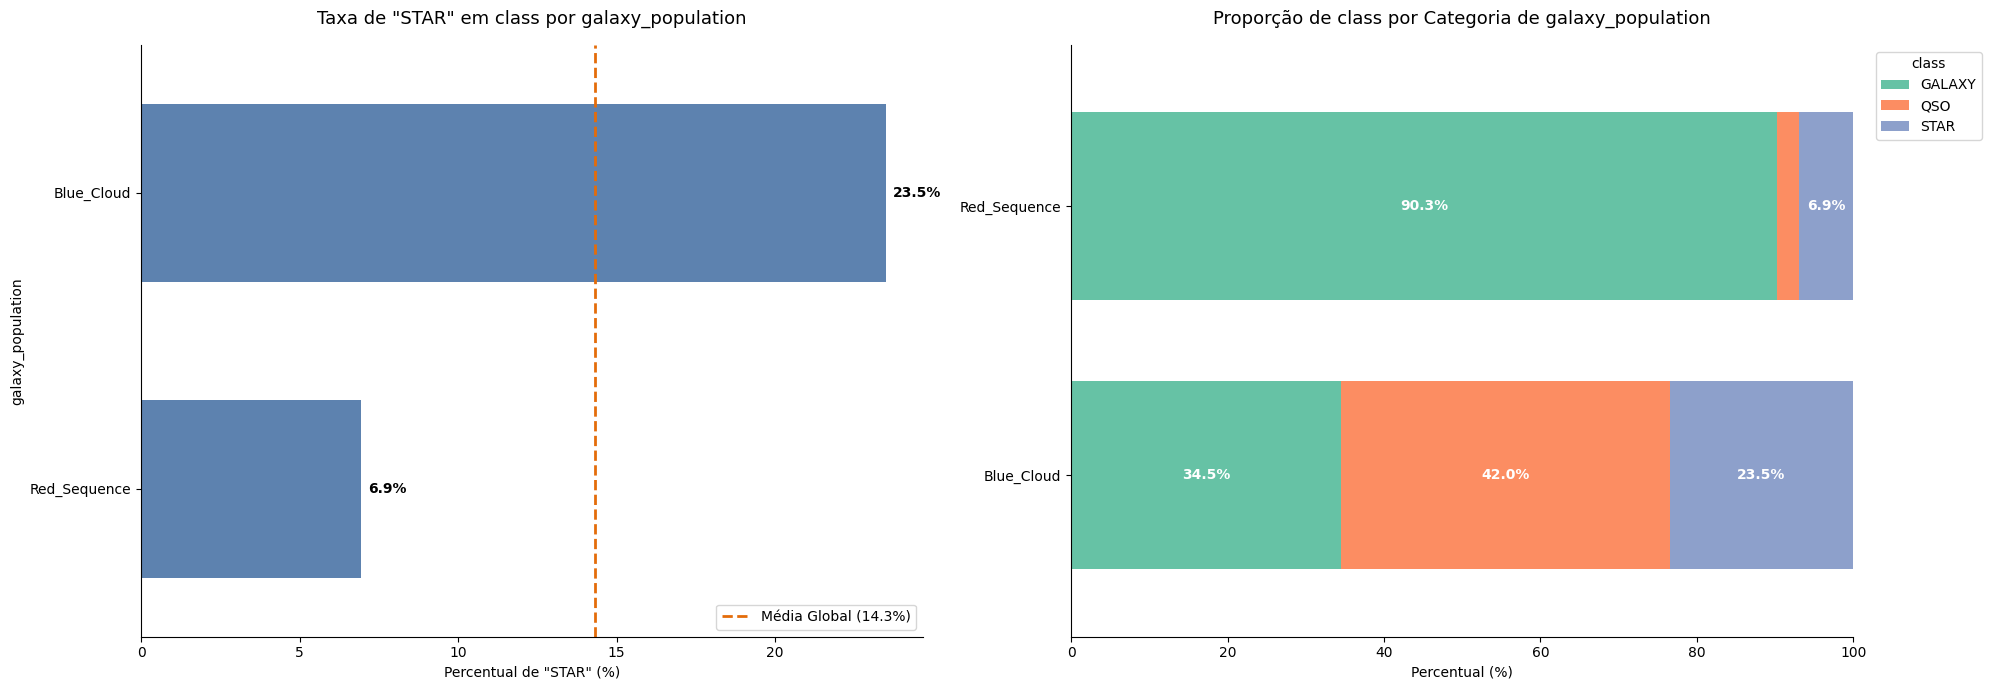

In [38]:
plot_cat_vs_target(df, col_categorica='galaxy_population', col_target='class', target_sucesso='STAR')

# Split X and y

In [39]:
X_train = df.drop(columns='class')
y_train = df.loc[:, ['class']]

X_test = df_test.copy()

In [40]:
le = LabelEncoder()
y_train['class_encoded'] = le.fit_transform(y_train['class'])

In [ ]:
dump_pickle(le, '../artifacts/label_encoder.pkl')

In [42]:
X_train.to_parquet('../data/X_train_raw.parquet', engine='fastparquet')
y_train.to_parquet('../data/y_train.parquet', engine='fastparquet')

X_test.to_parquet('../data/X_test_raw.parquet', engine='fastparquet')